Calculating Expected Loss 

- **probability of default (PD) * Loss given default (LGD) * Exposure at default (EAD)**
- establish dependant variable ie what to predict - default or non default
- default definition - eg payment 90 days overdue, fraud
- new variable - 1 default, 0 non default
- Logistic regression where the dependant var is whether the customer defaulted or  not, estimates the relationship between two things.
- Outcome of interest is the non default or default event
- Odds ratio = ratio of non defaults to defaults
- All independent variables should be dummy variables/binary categorical variables or indicator variables
- Transform continous variables to dummy variables
- The greater the value of independent variable the lower the probability of default
- **Fine classing** - turning continous variables into categories
- Weight of evidence (WoE) - shows to what extend an independent variable will predict a dependant variable
   - The formula of the weight of evidence is the natural logarithm of the ratio of the proportion of observations of the first type of outcome of the dependent variable that fall into the respective category of the independent variable and the proportion of observations of the second type of outcome of the dependent variable that fall into the respective category of the independent variable.
   - The two types of outcome are non defaulted or good and defaulted or bad. So the weight of evidence would be the natural logarithm of the ratio of the proportion of goods from the total number of goods that fall into the category to the proportion of bads from the total number of bads that fall into a category.
   - WoE tells us: How strongly a category is associated with: Good loans vs Bad loans - It measures how powerful each category is at separating good and bad borrowers.
- **Course classing** - constructing new catgeories based on the intitial ones. Categories with similar WoE are bundled together which lowers the number of dummies hence improving the pd model
- Information value used for var selection, preselect predictors  - how much information the original dependant variable brings with respect to explaining the dependant variable IV < 0.02 no predictive power, 0.02 < IV < 0.1 weak power, 0.1 <IV 0.3 medium power, 01. <IV <0.5 strong, 0,5 < IV suspiciously high too good to be true 

## PD model

### Data preparation

**Dependant variable : Good/bad (default) Definition default and non default accounts**

#### Import libraries and data 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#display all columns 
pd.options.display.max_columns = None

In [3]:
# Load the file
loan_data = pd.read_parquet('loan_data_cleaned.parquet')

In [4]:
loan_data.columns.values

array(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'veri

In [5]:
loan_data.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,days_since_earliest_cr_line,mths_since_earliest_cr_line,issue_d_date,days_since_issue_d,mths_since_issue_d,grade : A,grade : B,grade : C,grade : D,grade : E,grade : F,grade : G,sub_grade : A1,sub_grade : A2,sub_grade : A3,sub_grade : A4,sub_grade : A5,sub_grade : B1,sub_grade : B2,sub_grade : B3,sub_grade : B4,sub_grade : B5,sub_grade : C1,sub_grade : C2,sub_grade : C3,sub_grade : C4,sub_grade : C5,sub_grade : D1,sub_grade : D2,sub_grade : D3,sub_grade : D4,sub_grade : D5,sub_grade : E1,sub_grade : E2,sub_grade : E3,sub_grade : E4,sub_grade : E5,sub_grade : F1,sub_grade : F2,sub_grade : F3,sub_grade : F4,sub_grade : F5,sub_grade : G1,sub_grade : G2,sub_grade : G3,sub_grade : G4,sub_grade : G5,home_ownership : ANY,home_ownership : MORTGAGE,home_ownership : NONE,home_ownership : OTHER,home_ownership : OWN,home_ownership : RENT,verification_status : Not Verified,verification_status : Source Verified,verification_status : Verified,loan_status : Charged Off,loan_status : Current,loan_status : Default,loan_status : Does not meet the credit policy. Status:Charged Off,loan_status : Does not meet the credit policy. Status:Fully Paid,loan_status : Fully Paid,loan_status : In Grace Period,loan_status : Late (16-30 days),loan_status : Late (31-120 days),purpose : car,purpose : credit_card,purpose : debt_consolidation,purpose : educational,purpose : home_improvement,purpose : house,purpose : major_purchase,purpose : medical,purpose : moving,purpose : other,purpose : renewable_energy,purpose : small_business,purpose : vacation,purpose : wedding,addr_state : AK,addr_state : AL,addr_state : AR,addr_state : AZ,addr_state : CA,addr_state : CO,addr_state : CT,addr_state : DC,addr_state : DE,addr_state : FL,addr_state : GA,addr_state : HI,addr_state : IA,addr_state : ID,addr_state : IL,addr_state : IN,addr_state : KS,addr_state : KY,addr_state : LA,addr_state : MA,addr_state : MD,addr_state : ME,addr_state : MI,addr_state : MN,addr_state : MO,addr_state : MS,addr_state : MT,addr_state : NC,addr_state : NE,addr_state : NH,addr_state : NJ,addr_state : NM,addr_state : NV,addr_state : NY,addr_state : OH,addr_state : OK,addr_state : OR,addr_state : PA,addr_state : RI,addr_state : SC,addr_state : SD,addr_state : TN,addr_state : TX,addr_state : UT,addr_state : VA,addr_state : VT,addr_state : WA,addr_state : WI,addr_state : WV,addr_state : WY,initial_list_status : f,initial_list_status : w
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,None,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,None,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0,NaN,NaN,NaN,10.0,36,1985-01-01,12022 days,395,2011-12-01,2192 days,72,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0

#### Default and non default flag - dependant/target variable y

In [6]:
#data about borrower perfomance and repayment behaviour
loan_data ['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [7]:
#see how many values are there for each status
loan_data['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [8]:
#see proportion of accounts by status
loan_data ['loan_status'].value_counts() / loan_data['loan_status'].count()

loan_status
Current                                                0.480878
Fully Paid                                             0.396193
Charged Off                                            0.091092
Late (31-120 days)                                     0.014798
In Grace Period                                        0.006747
Does not meet the credit policy. Status:Fully Paid     0.004263
Late (16-30 days)                                      0.002612
Default                                                0.001784
Does not meet the credit policy. Status:Charged Off    0.001632
Name: count, dtype: float64

In [9]:
# #store good/bad flag or default 0 /non default 1 indicators
# # We create a new variable that has the value of '0' if a condition is met, and the value of '1' if it is not met.
# loan_data['good_bad'] = np.where(loan_data['loan_status'].isin(['Charged Off', 'Default',
#                                                        'Does not meet the credit policy. Status:Charged Off',
#                                                        'Late (31-120 days)']), 0, 1) 

In [10]:
#creating the dependant variable Y
#target/label engineering - define default 
default_statuses = [
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off',
    'Late (31-120 days)'
]

loan_data['good_bad'] = (~loan_data['loan_status'].isin(default_statuses)).astype(int)

In [11]:
loan_data['good_bad']

0         1
1         0
2         1
3         1
4         1
         ..
466280    1
466281    0
466282    1
466283    1
466284    1
Name: good_bad, Length: 466285, dtype: int64

#### Constructing independent variables X (features/predictors)

#### Splitting data - solution to overfitting

In [12]:
# Takes a set of inputs and a set of targets as arguments. Splits the inputs and the targets into four dataframes:
# Inputs - Train, Inputs - Test, Targets - Train, Targets - Test
# axis=0 means "Look at the rows" (top to bottom).
# axis=1 means "Look at the columns" (left to right).
# This is identical to using axis=1 and is harder to mess up:
# loan_data.drop(columns=['good_bad'])
# train_test_split(loan_data.drop('good_bad', axis = 1), loan_data['good_bad']) #Find the column named 'good_bad' and remove it from the side of the table."

In [13]:
train_test_split(
    loan_data.drop(columns='good_bad'), 
    loan_data['good_bad']
)

[        Unnamed: 0        id  member_id  loan_amnt  funded_amnt  \
 441367      441367  11708700   13680897       9600         9600   
 24319        24319    602871     773534      12000        12000   
 262356      262356  33441176   36084447       8500         8500   
 42554        42554  10149488   12001033       4800         4800   
 27144        27144    558800     719301      11200        11200   
 ...            ...       ...        ...        ...          ...   
 270023      270023  32519015   35132253      23000        23000   
 32397        32397    483485     615249      25000        25000   
 370249      370249  18925815   21178457      20000        20000   
 358029      358029  11656594   13628760      12000        12000   
 273688      273688  32118162   34721330       5000         5000   
 
         funded_amnt_inv        term  int_rate  installment grade sub_grade  \
 441367       9600.00000   36 months     13.65       326.48     C        C1   
 24319       11995.50805

In [14]:
# X_train, X_test, y_train, y_test = train_test_split(
#     loan_data.drop(columns='good_bad'), 
#     loan_data['good_bad']
# )

In [15]:
# loan_data_inputs_train, loan_data_inputs_test,loan_data_targets_train, loan_data_targets_test = train_test_split(
#                 loan_data.drop('good_bad', axis = 1), 
#                 loan_data['good_bad']
# )

In [16]:
loan_data_inputs_train, loan_data_inputs_test,loan_data_targets_train, loan_data_targets_test = train_test_split(
                loan_data.drop(columns= 'good_bad'), 
                loan_data['good_bad']
)  #default 75/25 split for sklearn and shuffle = true

In [17]:
loan_data_inputs_train.shape

(349713, 209)

In [18]:
loan_data_targets_train.shape

(349713,)

In [19]:
loan_data_inputs_test.shape

(116572, 209)

In [20]:
loan_data_targets_test.shape

(116572,)

In [21]:
# loan_data_inputs_train, loan_data_inputs_test,loan_data_targets_train, loan_data_targets_test = train_test_split(
#     loan_data.drop(columns='good_bad'), 
#     loan_data['good_bad'], 
#     test_size = 0.2,
#     random_state = 42
# )

In [22]:
loan_data_inputs_train, loan_data_inputs_test,loan_data_targets_train, loan_data_targets_test  = train_test_split(
    loan_data.drop(columns='good_bad'), 
    loan_data['good_bad'],
    test_size=0.2,
    random_state=42,  #shuffling pattern
    stratify=loan_data['good_bad']  #fairness - keep the same Good/Bad ratio.
)

In [23]:
loan_data_inputs_train.shape  #373,028 rows (observations) 209 variables (features)

(373028, 209)

In [24]:
loan_data_targets_train.shape

(373028,)

In [25]:
loan_data_inputs_test.shape

(93257, 209)

In [26]:
loan_data_targets_test.shape

(93257,)

#### Preprocessing discrete values

In [27]:
#independent var are in inputs df and the dependant var are in the target df
df_inputs_prepr = loan_data_inputs_train
df_target_prepr = loan_data_targets_train

In [28]:
df_inputs_prepr['grade'].unique()

array(['A', 'D', 'B', 'F', 'C', 'E', 'G'], dtype=object)

In [29]:
#glue the two columns side by side into one small df
df1 = pd.concat([df_inputs_prepr['grade'], df_target_prepr], axis =1)
df1.head()

,grade,good_bad
456615,A,1
451541,D,1
394474,D,1
110294,A,1
139343,B,0


##### WoE for variable grade

In [30]:
# 1. find proportion of bad and good borrowers by grade
#count no rows that contain each grade using groupby
# parametarize the code to make it reusable
df1.groupby(df1.columns.values[0], 
    as_index= False)[df1.columns.values[1]].count()

,grade,good_bad
0,A,59810
1,B,109344
2,C,100342
3,D,61713
4,E,28590
5,F,10606
6,G,2623


In [31]:
# # Use iloc-style logic to get the names
# col_to_group = df1.columns[0]  
# col_to_count = df1.columns[1]  

# df1.groupby(col_to_group, as_index=False)[col_to_count].count()

In [32]:
#proportion of borrowers in each group by calculating average of good & bad 
df1.groupby(df1.columns.values[0], 
    as_index= False)[df1.columns.values[1]].mean()

,grade,good_bad
0,A,0.961361
1,B,0.921422
2,C,0.885870
3,D,0.845527
4,E,0.804477
5,F,0.758061
6,G,0.721693


In [33]:
#merge
df1 = pd.concat([df1.groupby(df1.columns.values[0], as_index = False)[df1.columns.values[1]].count(),
                df1.groupby(df1.columns.values[0], as_index = False)[df1.columns.values[1]].mean()], axis = 1)
df1

,grade,good_bad,grade,good_bad
0,A,59810,A,0.961361
1,B,109344,B,0.921422
2,C,100342,C,0.885870
3,D,61713,D,0.845527
4,E,28590,E,0.804477
5,F,10606,F,0.758061
6,G,2623,G,0.721693


In [34]:
#return only the grade, good bad count and mean
df1 = df1.iloc[:, [0,1,3]]
df1

,grade,good_bad,good_bad
0,A,59810,0.961361
1,B,109344,0.921422
2,C,100342,0.885870
3,D,61713,0.845527
4,E,28590,0.804477
5,F,10606,0.758061
6,G,2623,0.721693


In [35]:
#rename columns
df1.columns = [df1.columns.values[0], 'n_obs', 'prop_good']
df1

,grade,n_obs,prop_good
0,A,59810,0.961361
1,B,109344,0.921422
2,C,100342,0.885870
3,D,61713,0.845527
4,E,28590,0.804477
5,F,10606,0.758061
6,G,2623,0.721693


In [36]:
# proportion of observations that fall into each grade
df1['prop_n_obs'] = df1['n_obs'] / df1['n_obs'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs
0,A,59810,0.961361,0.160336
1,B,109344,0.921422,0.293125
2,C,100342,0.885870,0.268993
3,D,61713,0.845527,0.165438
4,E,28590,0.804477,0.076643
5,F,10606,0.758061,0.028432
6,G,2623,0.721693,0.007032


In [37]:
#number of good borrowers and bad borrowers by grade group
# We multiply the values of one column by the values of another column
df1['n_good'] = df1['prop_good'] * df1['n_obs']
df1['n_bad'] = (1 - df1['prop_good']) * df1['n_obs']
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad
0,A,59810,0.961361,0.160336,57499.0,2311.0
1,B,109344,0.921422,0.293125,100752.0,8592.0
2,C,100342,0.885870,0.268993,88890.0,11452.0
3,D,61713,0.845527,0.165438,52180.0,9533.0
4,E,28590,0.804477,0.076643,23000.0,5590.0
5,F,10606,0.758061,0.028432,8040.0,2566.0
6,G,2623,0.721693,0.007032,1893.0,730.0


In [38]:
# calculate % of bad and good borrowers for each grade
df1['prop_n_good'] = df1['n_good'] / df1['n_good'].sum()
df1['prop_n_bad'] = df1['n_bad'] / df1['n_bad'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad
0,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678
1,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723
2,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801
4,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097
5,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932
6,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904


In [39]:
#calculate WoE of var grade using the natural algorithm of a number
df1['WoE'] = np.log(df1['prop_n_good'] / df1['prop_n_bad'])
# We take the natural logarithm of a variable and save the result in a nex variable.
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232
1,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975
2,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915
4,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340
5,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774
6,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981


In [40]:
#sort by WoE to see borrowers who have the highest default rate first
df1 = df1.sort_values(['WoE'])
df1 = df1.reset_index(drop = True) #reset the index of a df and overwrite it.
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE
0,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981
1,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774
2,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915
4,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620
5,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975
6,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232


In [41]:
#calcluate diff in the proportionns of good loans and diff of WoE between two subsequent categories, how much "riskier" or "safer" that grade is compared to the one above it.
df1['diff_prop_good'] = df1['prop_good'].diff().abs() #take the difference between two subsequent values of a column. Then, we take the absolute value of the result.
df1['diff_WoE'] = df1['WoE'].diff().abs() #take the difference between two subsequent values of a column. Then, we take the absolute value of the result.
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE
0,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981,NaN,NaN
1,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774,0.036369,0.189207
2,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340,0.046416,0.272434
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915,0.041050,0.285425
4,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620,0.040343,0.349295
5,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975,0.035552,0.412595
6,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232,0.039939,0.752257


##### IV for grade variable

In [42]:
#< 0.02 Not useful, 0.02 – 0.1 Weak, 0.1 – 0.3 Medium, 0.3 – 0.5Strong, >0.5 Suspiciously strong
# calculate information value = sum of the proportion of good borrowers for the respective categories minus the proportion of bad borrowers for the respective categories 
df1['IV'] = (df1['prop_n_good'] - df1['prop_n_bad']) * df1['WoE']
df1['IV'] = df1['IV'].sum()
df1

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981,NaN,NaN,0.292145
1,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774,0.036369,0.189207,0.292145
2,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340,0.046416,0.272434,0.292145
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915,0.041050,0.285425,0.292145
4,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620,0.040343,0.349295,0.292145
5,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975,0.035552,0.412595,0.292145
6,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232,0.039939,0.752257,0.292145


#### Automating calculations

In [43]:
# import scorecardpy as sc

# calculates the (IV) of every column in your data
# iv_summary = sc.iv(df_inputs_preprocessing, y='good_bad')
# print(iv_summary)

In [44]:
# WoE function for any pair of categoircal var and dependant var
def woe_discrete(df, discrete_variabe_name, good_bad_variable_df):
    df = pd.concat([df[discrete_variabe_name], good_bad_variable_df], axis = 1)
    df = pd.concat([df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].count(),
                    df.groupby(df.columns.values[0], as_index = False)[df.columns.values[1]].mean()], axis = 1)
    df = df.iloc[:, [0, 1, 3]]
    df.columns = [df.columns.values[0], 'n_obs', 'prop_good']
    df['prop_n_obs'] = df['n_obs'] / df['n_obs'].sum()
    df['n_good'] = df['prop_good'] * df['n_obs']
    df['n_bad'] = (1 - df['prop_good']) * df['n_obs']
    df['prop_n_good'] = df['n_good'] / df['n_good'].sum()
    df['prop_n_bad'] = df['n_bad'] / df['n_bad'].sum()
    df['WoE'] = np.log(df['prop_n_good'] / df['prop_n_bad'])
    df = df.sort_values(['WoE'])
    df = df.reset_index(drop = True)
    df['diff_prop_good'] = df['prop_good'].diff().abs()
    df['diff_WoE'] = df['WoE'].diff().abs()
    df['IV'] = (df['prop_n_good'] - df['prop_n_bad']) * df['WoE']
    df['IV'] = df['IV'].sum()
    return df

In [45]:
df_temp = woe_discrete(df_inputs_prepr, 'grade', df_target_prepr)
df_temp

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981,NaN,NaN,0.292145
1,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774,0.036369,0.189207,0.292145
2,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340,0.046416,0.272434,0.292145
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915,0.041050,0.285425,0.292145
4,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620,0.040343,0.349295,0.292145
5,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975,0.035552,0.412595,0.292145
6,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232,0.039939,0.752257,0.292145


#### Evaluating the WoE by visualizing it

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set()
sns.set_theme(style="whitegrid")


In [47]:
# function that visualizes the data
# Below we define a function that takes 2 arguments: a dataframe and a number.
# The number parameter has a default value of 0.
# This means that if we call the function and omit the number parameter, it will be executed with it having a value of 0.
# The function displays a graph.
def plot_by_woe(df_WoE, rotation_of_x_axis_labels = 0):
    #categories of independent var on x and WoE on y
    x = np.array(df_WoE.iloc[:, 0].apply(str))
    # Turns the values of the column with index 0 to strings, makes an array from these strings, and passes it to variable x.
    y = df_WoE['WoE']
    # Selects a column with label 'WoE' and passes it to variable y.
    plt.figure(figsize=(18, 6))
    # Sets the graph size to width 18 x height 6 inches
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    # Plots the datapoints with coordiantes variable x on the x-axis and variable y on the y-axis.
    # Sets the marker for each datapoint to a circle, the style line between the points to dashed, and the color to black.
    plt.xlabel(df_WoE.columns[0])
    # Names the x-axis with the name of the column with index 0.
    plt.ylabel('Weight of Evidence')
    # Names the y-axis 'Weight of Evidence'.
    plt.title(str('Weight of Evidence by ' + df_WoE.columns[0]))
    # Names the grapth 'Weight of Evidence by ' the name of the column with index 0.
    plt.xticks(rotation = rotation_of_x_axis_labels)
    # Rotates the labels of the x-axis a predefined number of degrees.

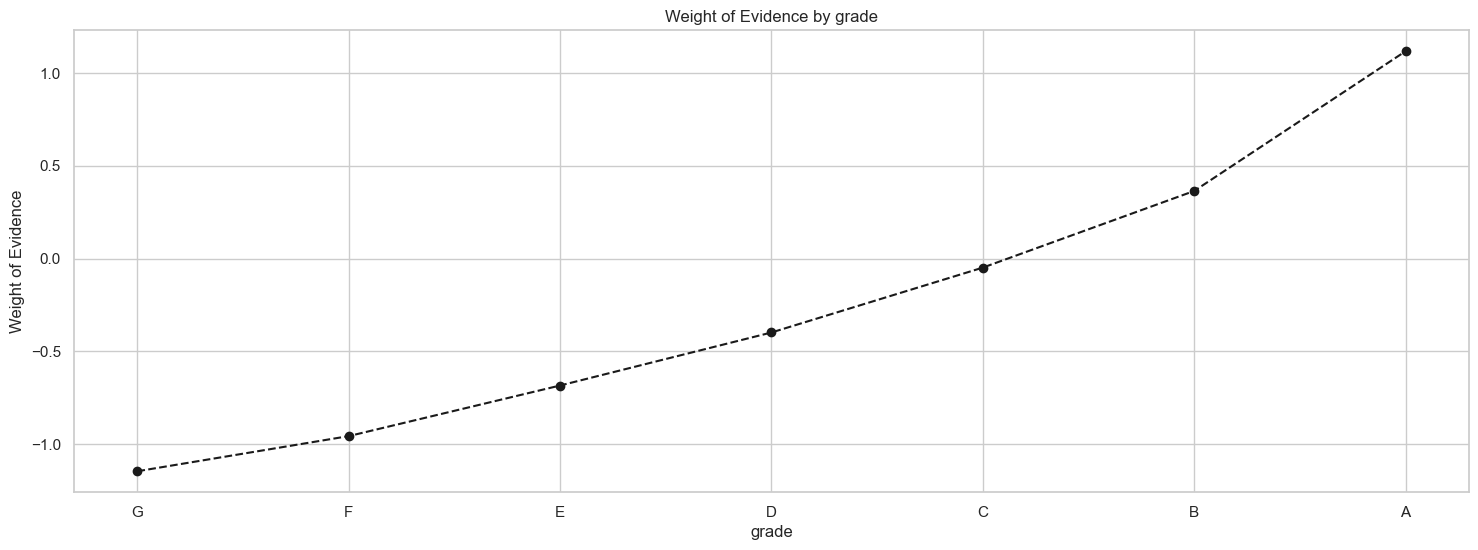

In [48]:
plot_by_woe (df_temp)

Loans with greater external rating are better on average

#### Creating dummy variables

In [49]:
#apply the func to calculate and visualize woe for all discrete variables
# reference category = category against which the impact of all others on the outcome will be accessed i.e  dummy var with categories with lowest woe
# 'home_ownership'
df_temp = woe_discrete(df_inputs_prepr, 'home_ownership', df_target_prepr)
# We calculate weight of evidence.
df_temp

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,OTHER,159,0.792453,0.000426,126.0,33.0,0.000379,0.000809,-0.758081,NaN,NaN,0.02166
1,NONE,41,0.853659,0.000110,35.0,6.0,0.000105,0.000147,-0.334267,0.061206,0.423814,0.02166
2,RENT,150776,0.874052,0.404195,131786.0,18990.0,0.396642,0.465738,-0.160588,0.020393,0.173678,0.02166
3,OWN,33313,0.890343,0.089304,29660.0,3653.0,0.089269,0.089591,-0.003605,0.016292,0.156984,0.02166
4,MORTGAGE,188739,0.904143,0.505965,170647.0,18092.0,0.513604,0.443714,0.146272,0.013800,0.149877,0.02166


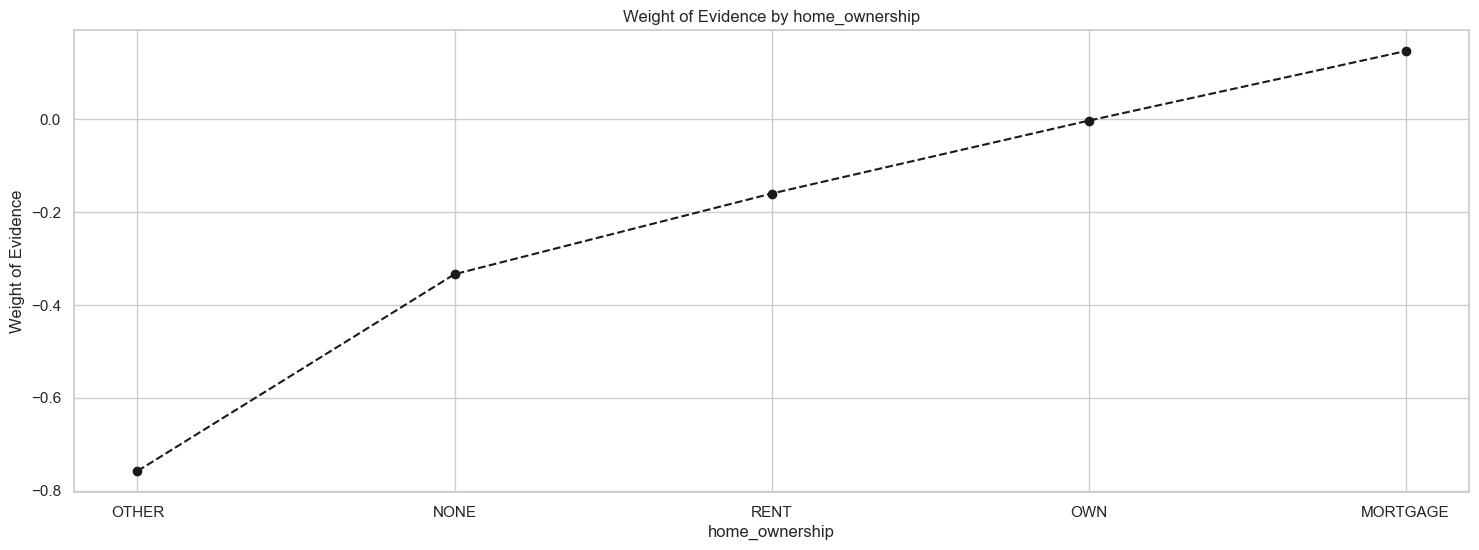

In [50]:
plot_by_woe(df_temp)

##### Category Binning or Grouping - prevents overfitting

In [51]:
# There are many categories with very few observations and many categories with very different "good" %.
# Therefore, we create a new discrete variable where we combine some of the categories.
# We combine them in one category, 'RENT_OTHER_NONE_ANY'.
# We end up with 3 categories: 'RENT_OTHER_NONE_ANY', 'OWN', 'MORTGAGE'.

# 1. Create the 'RENT_OTHER_NONE_ANY' category (Our Reference)
# "If the home_ownership column IS IN this list, mark the new column as 1"
# loan_data['home_ownership:RENT_OTHER_NONE_ANY'] = loan_data['home_ownership'].isin(['RENT', 'OTHER', 'NONE', 'ANY']).astype(int)

# # 2. Create the 'OWN' category
# loan_data['home_ownership:OWN'] = loan_data['home_ownership'].isin(['OWN']).astype(int)

# # 3. Create the 'MORTGAGE' category
# loan_data['home_ownership:MORTGAGE'] = loan_data['home_ownership'].isin(['MORTGAGE']).astype(int)
# 'RENT_OTHER_NONE_ANY' will be the reference category.

df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'] = sum([df_inputs_prepr['home_ownership : RENT'], 
                                                             df_inputs_prepr['home_ownership : OTHER'],
                                                             df_inputs_prepr['home_ownership : NONE'],
                                                             df_inputs_prepr['home_ownership : ANY']])

In [52]:
# 'addr_state'
df_inputs_prepr['addr_state'].unique()

array(['WI', 'TN', 'WA', 'FL', 'IL', 'TX', 'NY', 'WV', 'AL', 'NV', 'MD',
       'VA', 'CA', 'NH', 'DE', 'OH', 'NJ', 'NC', 'NM', 'AZ', 'CO', 'MA',
       'UT', 'GA', 'OR', 'SC', 'PA', 'IN', 'OK', 'MN', 'HI', 'MI', 'CT',
       'AK', 'MO', 'KY', 'AR', 'DC', 'KS', 'RI', 'LA', 'WY', 'MS', 'MT',
       'SD', 'VT', 'IA', 'NE', 'ID', 'ME'], dtype=object)

In [53]:
# We calculate weight of evidence.
df_temp = woe_discrete(df_inputs_prepr, 'addr_state', df_target_prepr)
df_temp

,addr_state,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,NE,8,0.500000,0.000021,4.0,4.0,0.000012,0.000098,-2.097855,NaN,NaN,inf
1,IA,7,0.857143,0.000019,6.0,1.0,0.000018,0.000025,-0.306096,0.357143,1.791759,inf
2,NV,5238,0.863498,0.014042,4523.0,715.0,0.013613,0.017536,-0.253207,0.006355,0.052889,inf
3,FL,25259,0.873273,0.067713,22058.0,3201.0,0.066389,0.078506,-0.167643,0.009775,0.085564,inf
4,HI,2012,0.876740,0.005394,1764.0,248.0,0.005309,0.006082,-0.135945,0.003467,0.031698,inf
5,AL,4698,0.877607,0.012594,4123.0,575.0,0.012409,0.014102,-0.127889,0.000868,0.008056,inf
6,MD,8811,0.882874,0.023620,7779.0,1032.0,0.023413,0.025310,-0.077926,0.005266,0.049963,inf
7,OK,3301,0.883369,0.008849,2916.0,385.0,0.008776,0.009442,-0.073130,0.000495,0.004796,inf
8,NY,32111,0.884339,0.086082,28397.0,3714.0,0.085468,0.091087,-0.063681,0.000970,0.009449,inf
9,NM,2077,0.884449,0.005568,1837.0,240.0,0.005529,0.005886,-0.062605,0.000110,0.001076,inf


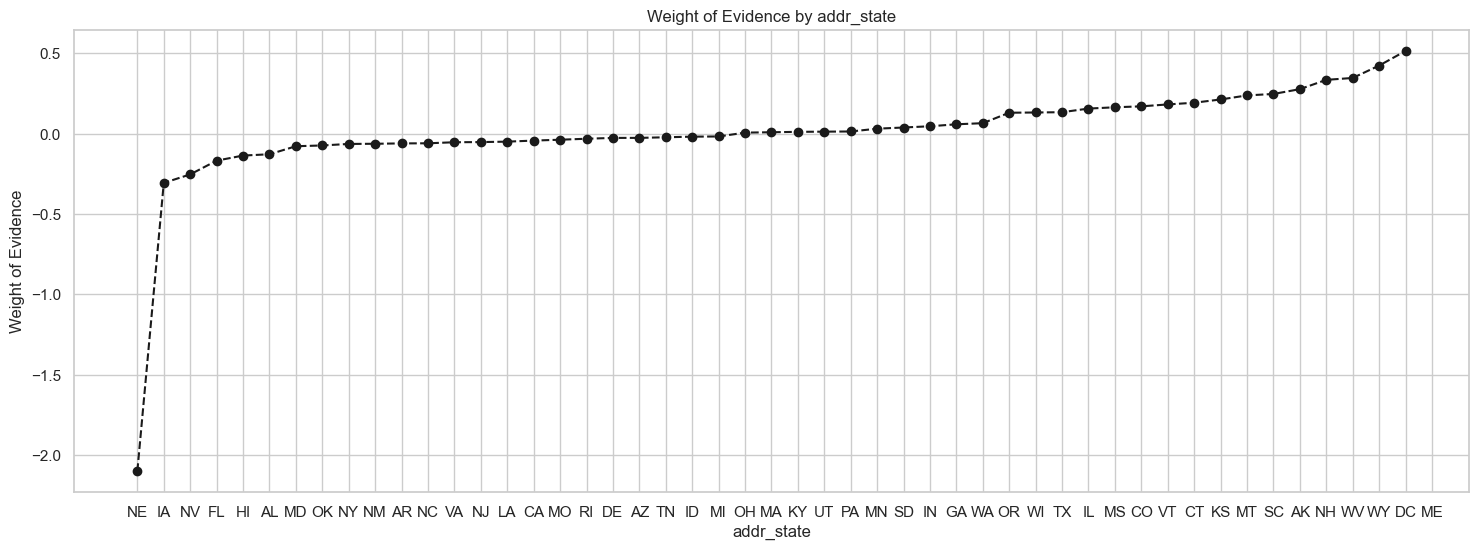

In [54]:
plot_by_woe(df_temp)

In [57]:
#create a dummy var for ND 
if ['addr_state : ND'] in df_inputs_prepr.columns.values:
    pass
else:
    df_inputs_prepr['addr_state : ND'] = 0

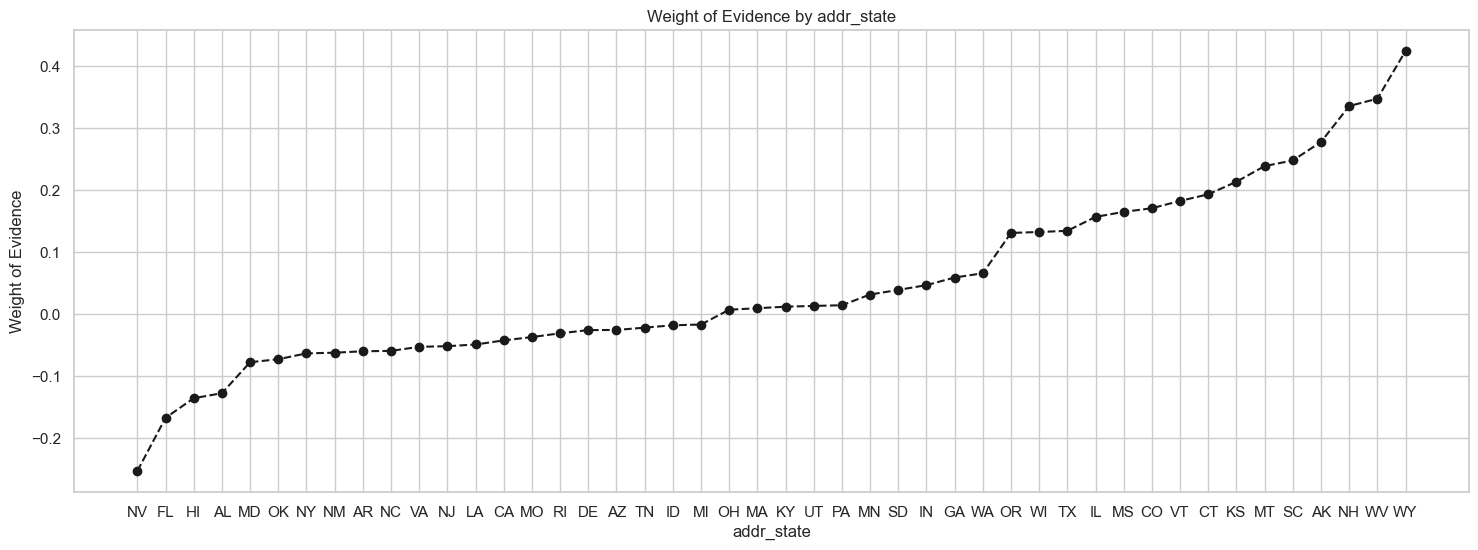

In [58]:
# the first two and last two have few observations
plot_by_woe(df_temp.iloc[2: -2, : ])


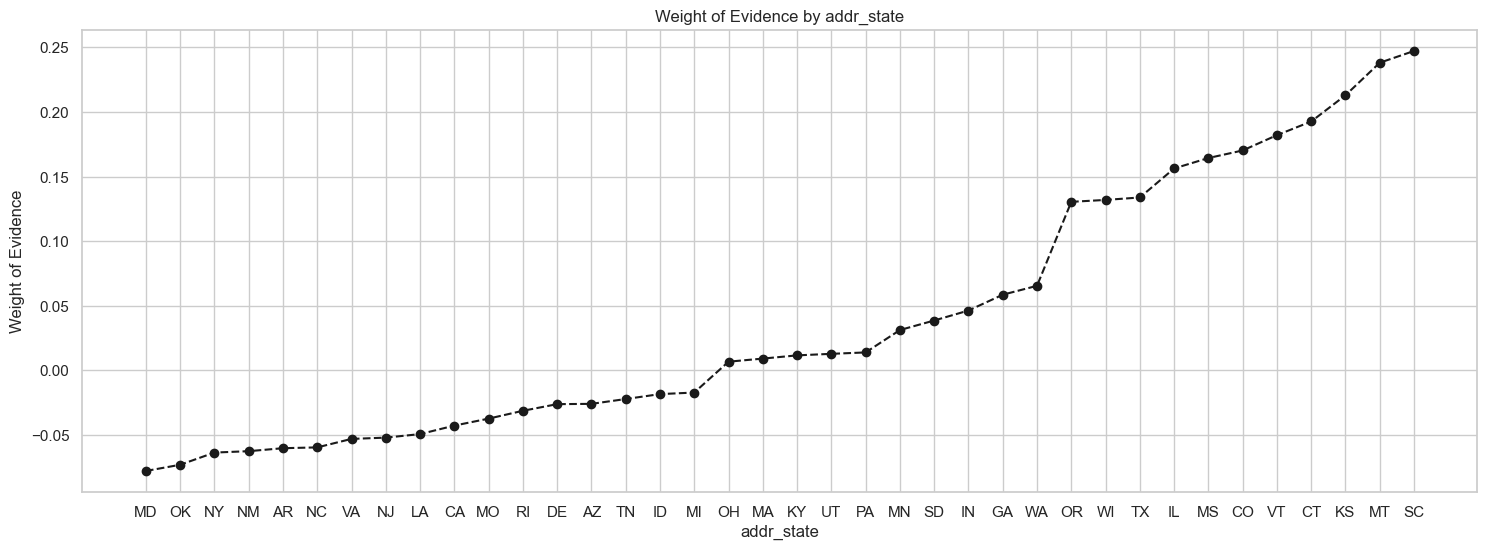

In [59]:
plot_by_woe(df_temp.iloc[6:-6,:])

In [61]:
# keep first state in diff category, same to the next 3 states, the first two states left out above
# place the state we have no info about in the worst/highest risk
#consider no of observations, similarity in woe
# leave out the reference category which is the category with the lowest woe

# Grouping states by risk (WoE) and number of observations
# prevents the model from making huge assumptions based on just a handful of borrowers.

df_inputs_prepr['addr_state : ND_NE_IA_NV_FL_HI_AL'] = sum([df_inputs_prepr['addr_state : ND'], df_inputs_prepr['addr_state : NE'],
                                                              df_inputs_prepr['addr_state : IA'], df_inputs_prepr['addr_state : NV'],
                                                              df_inputs_prepr['addr_state : FL'], df_inputs_prepr['addr_state : HI'],
                                                              df_inputs_prepr['addr_state : AL']])

df_inputs_prepr['addr_state : NM_VA'] = sum([df_inputs_prepr['addr_state : NM'], df_inputs_prepr['addr_state : VA']])

df_inputs_prepr['addr_state : OK_TN_MO_LA_MD_NC'] = sum([df_inputs_prepr['addr_state : OK'], df_inputs_prepr['addr_state : TN'],
                                                              df_inputs_prepr['addr_state : MO'], df_inputs_prepr['addr_state : LA'],
                                                              df_inputs_prepr['addr_state : MD'], df_inputs_prepr['addr_state : NC']])

df_inputs_prepr['addr_state : UT_KY_AZ_NJ'] = sum([df_inputs_prepr['addr_state : UT'], df_inputs_prepr['addr_state : KY'],
                                                              df_inputs_prepr['addr_state : AZ'], df_inputs_prepr['addr_state : NJ']])

df_inputs_prepr['addr_state : AR_MI_PA_OH_MN'] = sum([df_inputs_prepr['addr_state : AR'], df_inputs_prepr['addr_state : MI'],
                                                              df_inputs_prepr['addr_state : PA'], df_inputs_prepr['addr_state : OH'],
                                                              df_inputs_prepr['addr_state : MN']])

df_inputs_prepr['addr_state : RI_MA_DE_SD_IN'] = sum([df_inputs_prepr['addr_state : RI'], df_inputs_prepr['addr_state : MA'],
                                                              df_inputs_prepr['addr_state : DE'], df_inputs_prepr['addr_state : SD'],
                                                              df_inputs_prepr['addr_state : IN']])

df_inputs_prepr['addr_state : GA_WA_OR'] = sum([df_inputs_prepr['addr_state : GA'], df_inputs_prepr['addr_state : WA'],
                                                              df_inputs_prepr['addr_state : OR']])

df_inputs_prepr['addr_state : WI_MT'] = sum([df_inputs_prepr['addr_state : WI'], df_inputs_prepr['addr_state : MT']])

df_inputs_prepr['addr_state : IL_CT'] = sum([df_inputs_prepr['addr_state : IL'], df_inputs_prepr['addr_state : CT']])

df_inputs_prepr['addr_state : KS_SC_CO_VT_AK_MS'] = sum([df_inputs_prepr['addr_state : KS'], df_inputs_prepr['addr_state : SC'],
                                                              df_inputs_prepr['addr_state : CO'], df_inputs_prepr['addr_state : VT'],
                                                              df_inputs_prepr['addr_state : AK'], df_inputs_prepr['addr_state : MS']])

df_inputs_prepr['addr_state : WV_NH_WY_DC_ME_ID'] = sum([df_inputs_prepr['addr_state : WV'], df_inputs_prepr['addr_state : NH'],
                                                              df_inputs_prepr['addr_state : WY'], df_inputs_prepr['addr_state : DC'],
                                                              df_inputs_prepr['addr_state : ME'], df_inputs_prepr['addr_state : ID']])

#IA_NV_HI_ID_AL_FL' will be the reference category.

In [63]:
# calculate weight of evidence for'verification_status'
df_temp = woe_discrete(df_inputs_prepr, 'verification_status', df_target_prepr)
df_temp

,verification_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,Verified,134571,0.872045,0.360753,117352.0,17219.0,0.353200,0.422303,-0.178691,NaN,NaN,0.022522
1,Source Verified,119969,0.895723,0.321609,107459.0,12510.0,0.323424,0.306813,0.052726,0.023678,0.231417,0.022522
2,Not Verified,118488,0.906784,0.317638,107443.0,11045.0,0.323376,0.270883,0.177128,0.011061,0.124402,0.022522


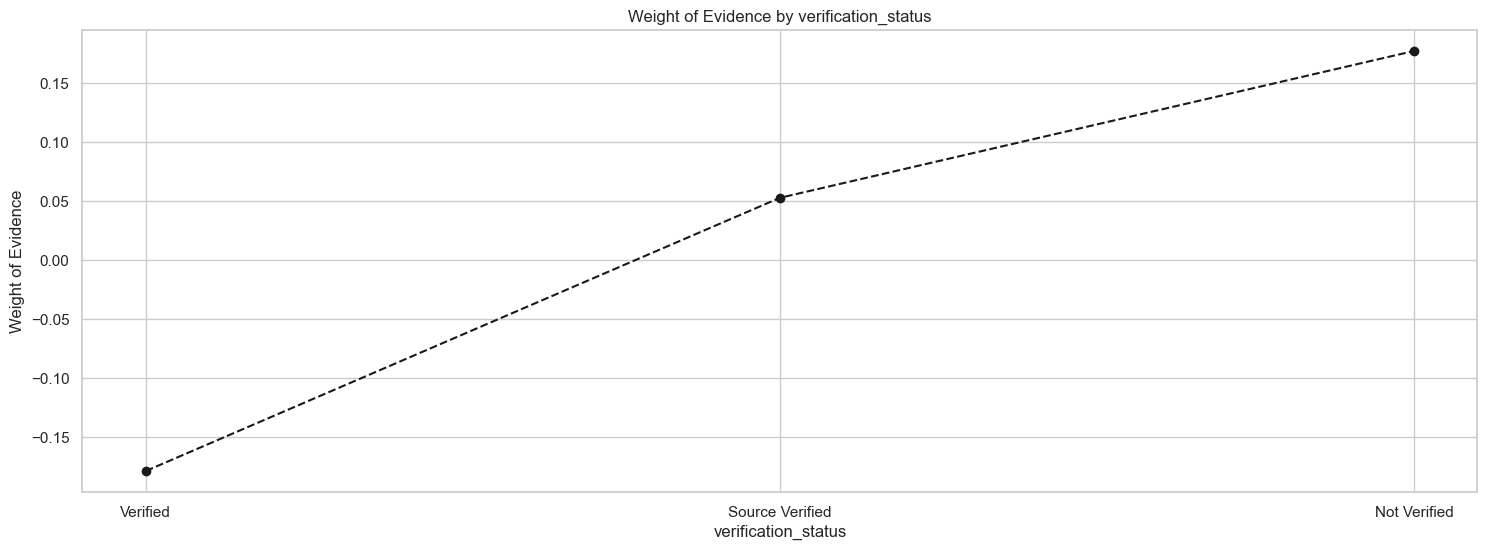

In [64]:
plot_by_woe(df_temp)

In [66]:
# calculate weight of evidence for 'purpose'
df_temp = woe_discrete(df_inputs_prepr, 'purpose', df_target_prepr)
df_temp

,purpose,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,small_business,5605,0.787333,0.015026,4413.0,1192.0,0.013282,0.029234,-0.788933,NaN,NaN,0.036668
1,educational,351,0.792023,0.000941,278.0,73.0,0.000837,0.001790,-0.760693,0.004690,0.028240,0.036668
2,renewable_energy,295,0.837288,0.000791,247.0,48.0,0.000743,0.001177,-0.459668,0.045265,0.301026,0.036668
3,moving,2397,0.848561,0.006426,2034.0,363.0,0.006122,0.008903,-0.374498,0.011273,0.085169,0.036668
4,house,1824,0.861294,0.004890,1571.0,253.0,0.004728,0.006205,-0.271777,0.012733,0.102721,0.036668
5,other,19006,0.861675,0.050951,16377.0,2629.0,0.049291,0.064477,-0.268581,0.000381,0.003196,0.036668
6,medical,3750,0.863467,0.010053,3238.0,512.0,0.009746,0.012557,-0.253469,0.001791,0.015112,0.036668
7,vacation,2003,0.875686,0.005370,1754.0,249.0,0.005279,0.006107,-0.145654,0.012220,0.107815,0.036668
8,wedding,1900,0.881053,0.005093,1674.0,226.0,0.005038,0.005543,-0.095419,0.005366,0.050235,0.036668
9,debt_consolidation,219196,0.886704,0.587613,194362.0,24834.0,0.584980,0.609065,-0.040346,0.005652,0.055072,0.036668


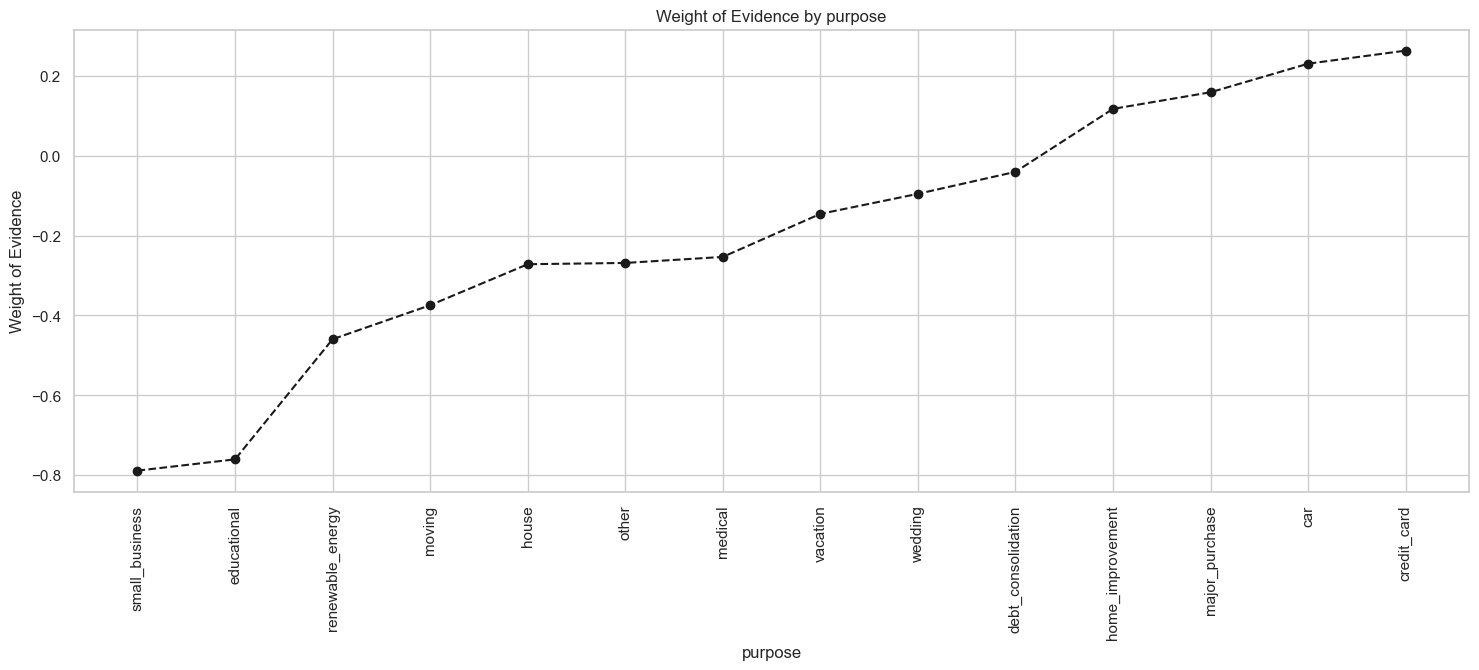

In [67]:
plot_by_woe(df_temp,90)

In [69]:
# We combine 'educational', 'small_business', 'wedding', 'renewable_energy', 'moving', 'house' in one category: 'educ__sm_b__wedd__ren_en__mov__house'.
# We combine 'other', 'medical', 'vacation' in one category: 'oth__med__vacation'.
# We combine 'major_purchase', 'car', 'home_improvement' in one category: 'major_purch__car__home_impr'.
# We leave 'debt_consolidtion' in a separate category.
# We leave 'credit_card' in a separate category.
# 'educ__sm_b__wedd__ren_en__mov__house' will be the reference category.
# Grouping loan purposes by risk (WoE)
# We use 'purpose : category' to match your naming convention

df_inputs_prepr['purpose : educ__sm_b__wedd__ren_en__mov__house'] = sum([
    df_inputs_prepr['purpose : educational'], 
    df_inputs_prepr['purpose : small_business'],
    df_inputs_prepr['purpose : wedding'], 
    df_inputs_prepr['purpose : renewable_energy'],
    df_inputs_prepr['purpose : moving'], 
    df_inputs_prepr['purpose : house']
])

df_inputs_prepr['purpose : oth__med__vacation'] = sum([
    df_inputs_prepr['purpose : other'], 
    df_inputs_prepr['purpose : medical'],
    df_inputs_prepr['purpose : vacation']
])

df_inputs_prepr['purpose : major_purch__car__home_impr'] = sum([
    df_inputs_prepr['purpose : major_purchase'], 
    df_inputs_prepr['purpose : car'],
    df_inputs_prepr['purpose : home_improvement']
])

In [72]:
# woe for 'initial_list_status'
df_temp = woe_discrete(df_inputs_prepr, 'initial_list_status', df_target_prepr)
df_temp

,initial_list_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,f,242325,0.879550,0.649616,213137.0,29188.0,0.641488,0.715848,-0.109678,NaN,NaN,0.025441
1,w,130703,0.911356,0.350384,119117.0,11586.0,0.358512,0.284152,0.232454,0.031806,0.342131,0.025441


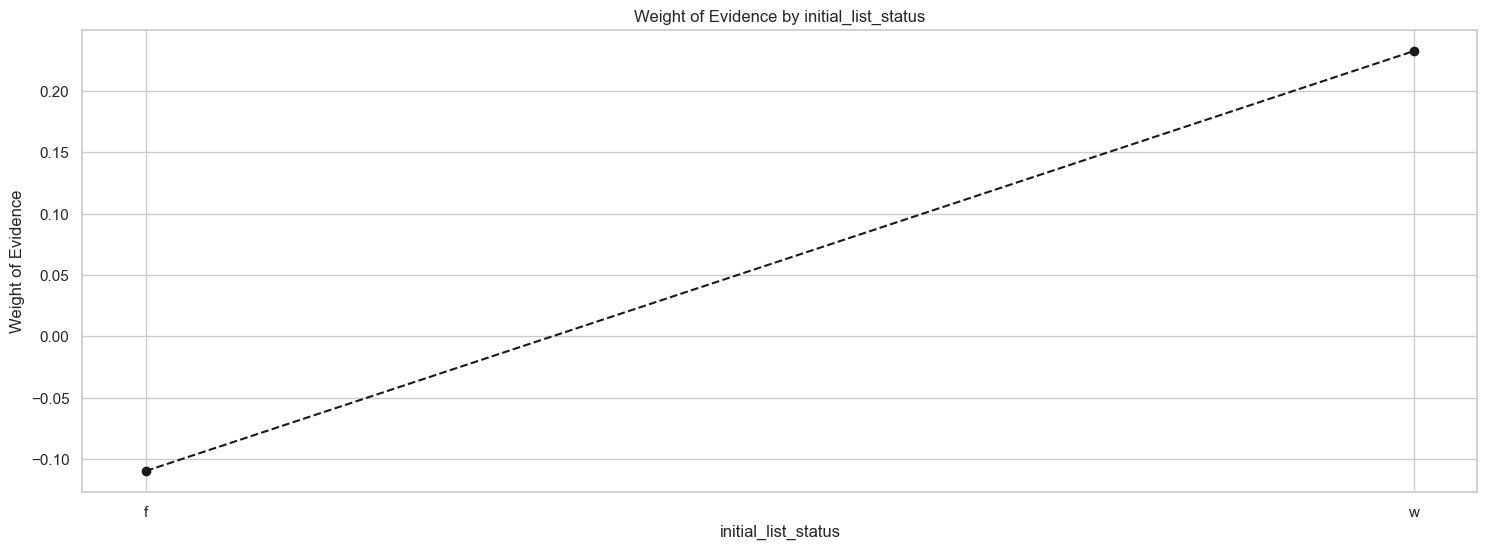

In [73]:
plot_by_woe(df_temp)